# <u>Linear Discriminant Analysis (LDA)</u>

## Topics

* [0. What is LDA](#what)
* [1. Core idea](#idea)
* [2. Univariate example](#example)
* [3. Why is LDA a linear classifier](#linear)
* [4. Classification rule](#rule)
* [5. Parameters to estimate](#parameters)
* [6. Effect of priors](#prior)
* [7. Key intuition and Limitations](#intuition)
* [8. LDA implementation](#lda)
* [9. LDA library](#library)

In [1]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
from scipy.stats import multivariate_normal # for multivariate normal pdf
from scipy.stats import norm # for normal pdf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # for LDA
print("Setup complete")

Setup complete


<a class="anchor" id="what"></a>
# 0. What LDA is

- Linear Discriminant Analysis (LDA) is a **generative** classification method
- It models how the data is generated by estimating class-conditional distributions $p(x \mid y=k)$ and uses Bayes theorem to compute class probabilities

<a class="anchor" id="idea"></a>
# 1. Core idea

Bayes theorem:
$$
p(y=k \mid x)=\frac{p(x \mid y=k)p(y=k)}{p(x)}=\frac{p(x \mid y=k)\pi_k}{\sum_{j=1}^g p(x \mid y=j)p(y=j)}=\frac{p(x, y=k)}{\sum_{j=1}^g p(x \mid y=j)\pi_j}
$$

- Posteriori: $p(y=k \mid x)$ is probability of class $y=k$ given observation $x$
- Likelihood: $p(x \mid y=k)$ is likelihood of observation $x$ being in class $y=k$
- Prior: $p(y=k)$ describes how common class $y=k$ is 
- Evidence: $p(x)$ is total probability of observing $x$ summed over all classes
- $\sum_{j=1}^g p(x \mid y=j)p(y=j)$ is the same for all classes
- classes $k=1,\ldots,g$

LDA assumes:

1. Each class $k$ has a multivariate Gaussian distribution:

$$
x \mid y=k \sim \mathcal{N}(\underbrace{\mu_k}_{\mathbb{R}^p},\underbrace{\Sigma}_{\mathbb{R}^{p \times p}}), \hspace{1 mm} \text{ with } p \text{ being number of features / dimensions of } x
$$

$$
p(x \mid y=k)=\frac{1}{(2\pi)^{p/2} \det(\Sigma)^{1/2}} \exp(-\frac{1}{2} (x-\mu_k)^\top \Sigma^{-1}(x-\mu_k)) , \hspace{1 mm} \text{ for class = }k
$$

2. All classes share the same covariance matrix:

$$
\Sigma_k = \Sigma \quad \forall k \in \{1,\ldots,g\}
$$

3. Using all this, compute posterior probabilities:

$$
p(y=k \mid x) \propto p(x \mid y=k)\pi_k
$$

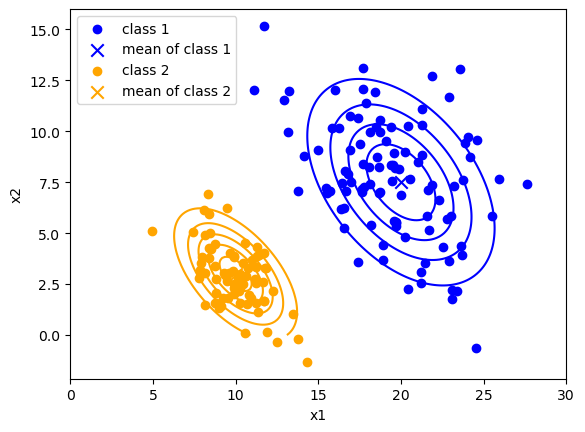

In [2]:
np.random.seed(1334) # for reproducibility

n1, n2 = 100, 75 # class sizes

mean_1 = np.array([20, 7.5])
cov_1 = np.array([[10, -4],
                  [-4, 8]]) # strong negative tilt and more spread on x1 axis

mean_2 = np.array([10, 3])
cov_2 = np.array([[4, -2],
                  [-2, 3]]) # less strong negative tilt but also more spread on x1 axis (same covariance structure)

class_1 = np.random.multivariate_normal(mean_1, cov_1, n1)
class_2 = np.random.multivariate_normal(mean_2, cov_2, n2)

# scatter plots
plt.scatter(class_1[:,0], class_1[:,1], color="blue",label="class 1")
plt.scatter(mean_1[0],mean_1[1],marker="x",label="mean of class 1",color="blue",s=80)
plt.scatter(class_2[:,0], class_2[:,1], color="orange",label="class 2")
plt.scatter(mean_2[0],mean_2[1],marker="x",label="mean of class 2",color="orange",s=80)
plt.legend()

# grid
x1 = np.linspace(0, 30, 200)
x2 = np.linspace(0, 15, 200)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))

# Contours: Each contour line connects points with the same probability density value 
# Along one contour, the likelihood of observing a point is constant
rv1 = multivariate_normal(mean_1, cov_1)
rv2 = multivariate_normal(mean_2, cov_2)

plt.contour(X1, X2, rv1.pdf(pos), colors='blue', levels=5)
plt.contour(X1, X2, rv2.pdf(pos), colors='orange', levels=5)

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

<a class="anchor" id="example"></a>
# 2. Univariate example

- Classify a new person as male or female based on ther height
- First Setup: Equal class sizes and same variance
- Second Setup: Unequal class sizes and same variance

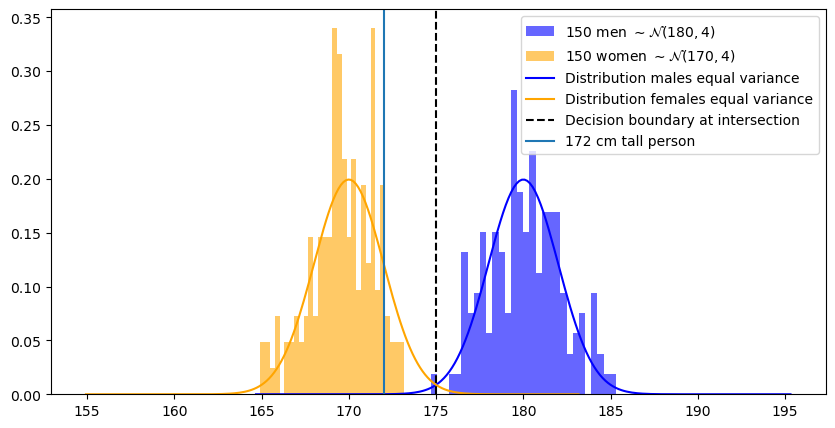

In [3]:
# First Setup: Equal class sizes

np.random.seed(1528) # for reproducibility
n = 150 # equal number of men and women

# Male data
mean_male = 180
std_male = 2
heights_male = np.random.normal(mean_male, std_male, n)
heights_male_line = np.linspace(np.min(heights_male)-10, np.max(heights_male)+10, 200)
pdf_male = norm.pdf(heights_male_line, loc=mean_male, scale=std_male)

# Female data
mean_female = 170
std_female = 2  
heights_female = np.random.normal(mean_female, std_female, n)
heights_female_line = np.linspace(np.min(heights_female)-10, np.max(heights_female)+10, 200)
pdf_female = norm.pdf(heights_female_line, loc=mean_female, scale=std_female)

# Plot
plt.figure(figsize=(10,5))
plt.hist(heights_male, bins=30, density=True, label=rf"{n} men $\sim \mathcal{{N}}(180,4)$", alpha=0.6,color="blue")
plt.hist(heights_female, bins=30, density=True, label=rf"{n} women $\sim \mathcal{{N}}(170,4)$", alpha=0.6,color="orange")

plt.plot(heights_male_line, pdf_male,color="blue",label="Distribution males equal variance")
plt.plot(heights_female_line, pdf_female,color="orange",label="Distribution females equal variance")

plt.axvline(175,linestyle="--",color="black",label="Decision boundary at intersection")
plt.axvline(172,label="172 cm tall person")

plt.legend()
plt.show()

In [4]:
x = 172

# Likelihoods
p_x_given_man = norm.pdf(x, loc=mean_male, scale=std_male)
p_x_given_woman = norm.pdf(x, loc=mean_female, scale=std_female)

# Posterior
p_man_given_x = p_x_given_man / (p_x_given_man + p_x_given_woman)
p_woman_given_x = p_x_given_woman / (p_x_given_man + p_x_given_woman)

print("P(man | x=172):", p_man_given_x)
print("P(woman | x=172):", p_woman_given_x)

P(man | x=172): 0.0005527786369235996
P(woman | x=172): 0.9994472213630764


**The equal (co)variance structure allows a <u>linear</u> descision boundary**

Compute probability that a 172 cm tall person is male

$$
\begin{align*}
p(y=\text{man} \mid x=172) &=\frac{p(x=172 \mid y = \text{man})p(y=\text{man})}{p(x=172)} \\
&=\frac{p(x=172 \mid y = \text{man})p(y=\text{man})}{\sum_{j \in \{\text{man},\text{woman}\}}p(x=172 \mid y = j)p(y=j)} \\
&=\frac{p(x=172 \mid y = \text{man})p(y=\text{man})}{p(x=172 \mid y = \text{man})p(y=\text{man})+p(x=172 \mid y = \text{woman})p(y=\text{woman})} \\
&=\frac{p(x=172 \mid y = \text{man})\pi_\text{man}}{p(x=172 \mid y = \text{man}) \pi_\text{man}+p(x=172 \mid y = \text{woman})\pi_\text{woman}} \\
&\text{Since we have equal class sizes }\pi_\text{man}=\pi_\text{woman}= \text{ they cancel out} \\
&=\frac{p(x=172 \mid y = \text{man})}{p(x=172 \mid y = \text{man})+p(x=172 \mid y = \text{woman})} \\
\end{align*} 
$$

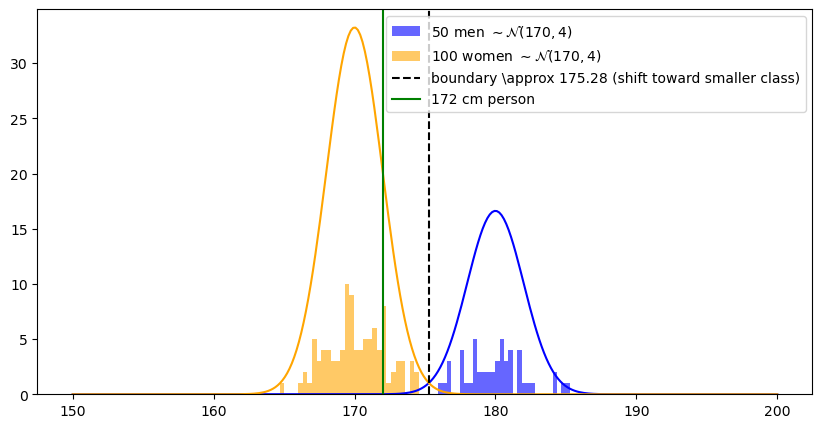

In [5]:
# Second Setup: Unequal class sizes

np.random.seed(1528)
n_men = 50
n_women = 100

mean_male = 180
std_male = 2
mean_female = 170
std_female = 2

# Data
heights_male = np.random.normal(mean_male, std_male, n_men)
heights_female = np.random.normal(mean_female, std_female, n_women)

x = np.linspace(150, 200, 300)

pdf_male = norm.pdf(x, loc=mean_male, scale=std_male)
pdf_female = norm.pdf(x, loc=mean_female, scale=std_female)

# Scale PDFs to histogram counts
bin_width = (x.max() - x.min()) / 30
pdf_male_scaled = pdf_male * n_men * bin_width
pdf_female_scaled = pdf_female * n_women * bin_width

# Priors
prior_male = n_men / (n_men + n_women)
prior_female = n_women / (n_men + n_women)

# Decision boundary
intersection = (mean_male + mean_female)/2 + \
               (std_male**2 / (mean_male - mean_female)) * \
               np.log(prior_female / prior_male)

# Plot
plt.figure(figsize=(10,5))

plt.hist(heights_male, bins=30, alpha=0.6, color="blue", label=rf"{n_men} men $\sim \mathcal{{N}}(170,4)$")
plt.hist(heights_female, bins=30, alpha=0.6, color="orange", label=rf"{n_women} women $\sim \mathcal{{N}}(170,4)$")

plt.plot(x, pdf_male_scaled, color="blue")
plt.plot(x, pdf_female_scaled, color="orange")

plt.axvline(intersection, linestyle="--", color="black", label=rf"boundary \approx {intersection:.2f} (shift toward smaller class)")
plt.axvline(172, color="green", label="172 cm person")

plt.legend()
plt.show()

In [6]:
x_val = 172

# Likelihoods
p_x_given_man = norm.pdf(x_val, loc=mean_male, scale=std_male)
p_x_given_woman = norm.pdf(x_val, loc=mean_female, scale=std_female)

# Posterior with priors
p_man_given_x = (p_x_given_man * prior_male) / (p_x_given_man * prior_male + p_x_given_woman * prior_female)

print("P(man | x=172):", p_man_given_x)

p_woman_given_x = (p_x_given_woman * prior_female) / (p_x_given_man * prior_male + p_x_given_woman * prior_female)

print("P(woman | x=172):", p_woman_given_x)

P(man | x=172): 0.0002764657306366685
P(woman | x=172): 0.9997235342693633


**The equal (co)variance structure allows a <u>linear</u> descision boundary**

Compute probability that a 172 cm tall person is male

$$
\begin{align*}
p(y=\text{man} \mid x=172) &=\frac{p(x=172 \mid y = \text{man})p(y=\text{man})}{p(x=172)} \\
&=\frac{p(x=172 \mid y = \text{man})p(y=\text{man})}{\sum_{j \in \{\text{man},\text{woman}\}}p(x=172 \mid y = j)p(y=j)} \\
&=\frac{p(x=172 \mid y = \text{man})p(y=\text{man})}{p(x=172 \mid y = \text{man})p(y=\text{man})+p(x=172 \mid y = \text{woman})p(y=\text{woman})} \\
&=\frac{p(x=172 \mid y = \text{man})\pi_\text{man}}{p(x=172 \mid y = \text{man}) \pi_\text{man}+p(x=172 \mid y = \text{woman})\pi_\text{woman}} \\
&\text{Since we have unequal class sizes }\pi_\text{man} \neq \pi_\text{woman}= \text{ they do not cancel out} \\
&=\frac{p(x=172 \mid y = \text{man})\frac{50}{150}}{p(x=172 \mid y = \text{man})\frac{50}{150}+p(x=172 \mid y = \text{woman})\frac{100}{150}} \\
\end{align*} 
$$

<a class="anchor" id="linear"></a>
# 3. Why is LDA a linear classifier

- Because all classes share the same covariance matrix, the resulting decision boundaries are linear (hyperplanes)
- The classifier can be written as: $$\underbrace{f_k(x)=w_{0k} + x^\top w_k}_{\text{affine linear function of }x} \hspace{1 mm} \text{ for }k=1,\ldots,g $$

- For $g=2$ a single discriminant function $f(x)=f_1(x)-f_0(x)=(w_{01} + x^\top w_1)-(w_{00} + x^\top w_0)=(w_1 - w_0)^\top x + (w_{01}-w_{00})$ for \{0,1\} response (or $f(x)=f_{+1}(x)-f_{-1}(x)$ for \{-1,+1\} response) is enough and then if $f(x) > 0 \rightarrow$ class 1 else $\rightarrow$ class 0.
    - Solve for either dimension of $x=\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ to get descision boundary
    $$
    \begin{align*}
    (w_1 - w_0)^\top x + (w_{01}-w_{00}) &=0 \hspace{1 mm} \mid \hspace{1 mm} b=(w_{01}-w_{00}) \\ \Leftrightarrow 
    (w_{1}^{(1)} - w_{0}^{(1)}) x_1+(w_{1}^{(2)} - w_{0}^{(2)}) x_2 + b &=0 \\ \Leftrightarrow 
    (w_{1}^{(1)} - w_{0}^{(1)}) x_1 + b &=-(w_{1}^{(2)} - w_{0}^{(2)})x_2 \\ \Leftrightarrow 
    -\frac{(w_{1}^{(1)} - w_{0}^{(1)}) x_1 + b}{w_{1}^{(2)} - w_{0}^{(2)}} &= x_2 \\

    \end{align*}
    $$

- For multiclasses $g > 2$ the classifier assigns $h(x)=\hat{y}=\underset{k \in \{1,\ldots,g\}}{\arg\max} f_k(x)$
    - &#128073; So the decision boundary is where two classes are tied: $f_k(x)=f_j(x)$ for any $(k,j)$ pair $(k \neq j)$
    - For each pair of classes $k$ and $j$, the boundary is: 
    $$
    \begin{align*}
    f_k(x)-f_j(x)=0 \\
    \end{align*}
    $$ 
    - So with $g$ classes:
        - We get $\frac{g(g-1)}{2}$ boundaries
        - Each boundary separates two classes

Derivation:

$$
\begin{align*}
p(y=k \mid x) &= \frac{p(x \mid y=k)\pi_k}{p(x)} \\

&\propto p(x \mid y=k)\pi_k \\

&= \frac{1}{(2\pi)^{p/2} \det(\Sigma)^{1/2}} \exp\left(-\frac{1}{2} (x-\mu_k)^\top \Sigma^{-1}(x-\mu_k)\right)\pi_k \\

&\propto  \exp\left(-\frac{1}{2} (x-\mu_k)^\top \Sigma^{-1}(x-\mu_k)\right)\pi_k \\



&= \exp\left(-\frac{1}{2}x^\top\Sigma^{-1}x +\frac{1}{2}x^\top\Sigma^{-1}\mu_k + \frac{1}{2}\mu_k^\top \Sigma^{-1}x - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k  \right)\pi_k \\

&x^\top\Sigma^{-1}\mu_k=\mu_k^\top \Sigma^{-1}x\\

&= \exp\left(-\frac{1}{2}x^\top\Sigma^{-1}x +x^\top\Sigma^{-1}\mu_k  - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k  \right)\pi_k \\

& a \cdot \exp(b+c)=\exp(\ln(a) + b + c)=\exp(\ln(a) + b)\exp(c) \\

&= \exp\left(\ln(\pi_k)-\frac{1}{2}x^\top\Sigma^{-1}x +x^\top\Sigma^{-1}\mu_k  - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k  \right) \\

&= \exp\left(\ln(\pi_k) - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k +x^\top\Sigma^{-1}\mu_k   \right) \exp\left(-\frac{1}{2}x^\top\Sigma^{-1}x\right) \\

&\exp\left(-\frac{1}{2}x^\top\Sigma^{-1}x\right) \text{ contains }x \text{ but is the same for all classes } \rightarrow \text{ leave it out} \\

&= \exp\left(\ln(\pi_k) - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k +x^\top\Sigma^{-1}\mu_k   \right) \hspace{1 mm} \mid \hspace{1 mm} \ln(\ldots) \text{ rank preserving transformation} \\

&= \underbrace{\ln(\pi_k) - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k}_{w_{0k}} +x^\top \underbrace{\Sigma^{-1}\mu_k}_{w_k} \\

&= w_{0k} + x^\top w_k =: f_k(x)

\end{align*}
$$


&#128073; Hence: LDA = linear classifier derived from probabilistic assumptions


<a class="anchor" id="rule"></a>
# 4. Classification rule

- Compute a score for each class: $$f_k(x)$$
- Predict the class with the highest score: $$h(x)=\hat{y}=\underset{k \in \{1,\ldots,g\}}{\arg\max} f_k(x)$$



<a class="anchor" id="parameters"></a>
# 5. Parameters to estimate


Class priors: $$\hat{\pi}_k=\frac{n_k}{n}$$






- $n$ is total number of observations
- $n_k$ number observation in class $k$

Class means: $$\hat{\mu}_k=\frac{1}{n_k} \sum_{i:y^{(i)}=k} x^{(i)}$$


Shared covariance matrix: $$\hat{\Sigma}=\frac{1}{n-g} \sum_{k=1}^g \sum_{i:y^{(i)}=k} (x^{(i)}-\hat{\mu}_k)(x^{(i)}-\hat{\mu}_k)^\top$$

- $g$ is number of classes

<a class="anchor" id="prior"></a>
# 6. Effect of prior

- Class priors $\pi_k$ influence the descision boundary:
    - Large prior $\rightarrow$ boundary shifts toward smaller class

- Important for imbalanced datasets

<a class="anchor" id="intuition"></a>
# 7. Key intuition and Limitations

## Intuition

- LDA separates classes by:
    - Considering distance from class means
    - Adjusted by shared covariance structure
- It effectively finds directions that best separate class means relative to variance


## Limitations

- Assumes:
    - Gaussian distributions
    - Equal covariance across classes
- May perform poorly if these assumptions are violated

&#128073; LDA is a generative classifier that assumes Gaussian class distributions with equal covariance, leading to linear decision boundaries.

<a class="anchor" id="lda"></a>
# 8. LDA implementation



{'classes': array([0, 1]), 'pi': {np.int64(0): 0.5, np.int64(1): 0.5}, 'mu': {np.int64(0): array([10.11420023,  1.89903985]), np.int64(1): array([20.0149507 ,  6.87499948])}, 'Sigma': array([[2.87681794, 0.60672019],
       [0.60672019, 1.92552914]]), 'Sigma_inv': array([[ 0.37235006, -0.11732479],
       [-0.11732479,  0.55630595]]), 'w': {np.int64(0): array([ 3.54321857, -0.13019923]), np.int64(1): array([6.64596015, 1.47635328])}, 'w0': {np.int64(0): np.float64(-18.487931454038144), np.int64(1): np.float64(-72.27739354510632)}}
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Accuracy: 1.0
Coefficients (w): [np.float64(3.1027415789

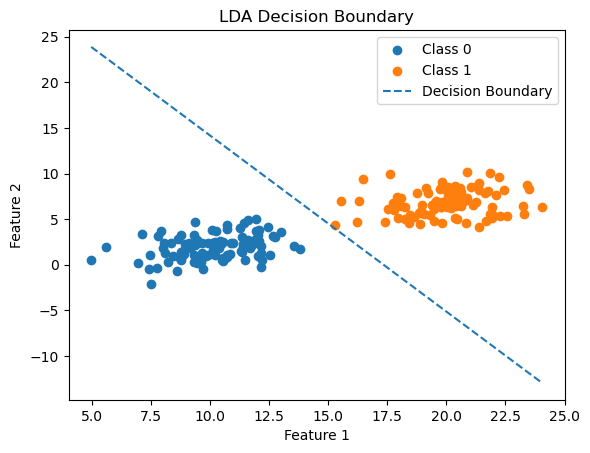

In [7]:
# Train function
def lda_fit(X, y):
    classes = np.unique(y) # get individual classes
    n, p = X.shape  # sample size and number of features/dimensions
    g = len(classes) # number of classes

    pi = {} # empty dictionray 
    mu = {} # empty dictionray 

    # Priors and means
    for k in classes:
        Xk = X[y == k] # filter rows according to classes
        pi[k] = len(Xk) / n # prior (k is now a key of pi with value len(XK)/n)
        mu[k] = np.mean(Xk, axis=0) # class mean (parameter of Gaussian p(x | y=k))

    # Shared covariance
    Sigma = np.zeros((p, p))
    for k in classes:
        Xk = X[y == k]
        for x in Xk:
            diff = (x - mu[k]).reshape(-1, 1)
            Sigma += diff @ diff.T 

    Sigma /= (n - g) # pooled (shared) covariance estimate across all classes
    Sigma_inv = np.linalg.inv(Sigma) 

    # Precompute weights
    w = {}
    w0 = {}

    # compute linear discriminant parameters (weights)
    for k in classes:
        w[k] = Sigma_inv @ mu[k]
        w0[k] = np.log(pi[k]) - 0.5 * mu[k].T @ Sigma_inv @ mu[k]

    # return dictionary of dictionaries
    return {
        "classes": classes,
        "pi": pi,
        "mu": mu,
        "Sigma": Sigma,
        "Sigma_inv": Sigma_inv,
        "w": w,
        "w0": w0
    }


# Prediction function
def lda_predict(model, X):
    classes = model["classes"]
    w = model["w"]
    w0 = model["w0"]

    preds = []
    for x in X:
        scores = {} # empty dictionary to later store score per class
        for k in classes:
            # for each row in X compute its score for every class
            # predicted class = class with highest discriminant score
            scores[k] = w0[k] + x @ w[k] # access values at key k inside w0 and w
        preds.append(max(scores, key=scores.get))

    return np.array(preds)


# Probabilities function
def lda_predict_proba(model, X):
    classes = model["classes"]
    w = model["w"]
    w0 = model["w0"]

    probs = []
    for x in X:
        scores = np.array([w0[k] + x @ w[k] for k in classes])
        exp_scores = np.exp(scores) # convert scores to probabilities using softmax (Bayes rule)
        probs.append(exp_scores / np.sum(exp_scores))

    return np.array(probs)


# Toy data
np.random.seed(1918)
X1 = np.random.multivariate_normal([10, 2], [[3, 1], [1, 2]], 100)
X2 = np.random.multivariate_normal([20, 7], [[3, 1], [1, 2]], 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

# Train
model = lda_fit(X, y)
print(model)

# Predict
preds = lda_predict(model, X)
print(preds)

print("Accuracy:", np.mean(preds == y))

coeffs_w=[model["w"][np.int64(1)][0]-model["w"][np.int64(0)][0],
          model["w"][np.int64(1)][1]-model["w"][np.int64(0)][1]]

interc_w0=model["w0"][np.int64(1)]-model["w0"][np.int64(0)]
print("Coefficients (w):",coeffs_w)
print("Intercept (w0):",interc_w0)


# Scatter plot of the data
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

# Convert your coefficients
w = np.array(coeffs_w)
b = interc_w0

# Decision boundary: w0 + w1*x1 + w2*x2 = 0
# Solve for x2:
# x2 = -(b + w1*x1) / w2

x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = -(b + w[0] * x_vals) / w[1]

# Plot decision boundary
plt.plot(x_vals, y_vals, linestyle="--", label="Decision Boundary")

# Labels and legend
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("LDA Decision Boundary")

plt.show()

Accuracy: 1.0
{'classes': array([0, 1, 2]), 'pi': {np.int64(0): 0.3333333333333333, np.int64(1): 0.3333333333333333, np.int64(2): 0.3333333333333333}, 'mu': {np.int64(0): array([10.04260806,  1.93933063]), np.int64(1): array([20.10089352,  6.64882209]), np.int64(2): array([14.97860261, 11.85032303])}, 'Sigma': array([[2.83353037, 1.09338761],
       [1.09338761, 2.05988966]]), 'Sigma_inv': array([[ 0.44382089, -0.23557973],
       [-0.23557973,  0.61050841]]), 'w': {np.int64(0): array([ 4.00025223, -1.18185727]), np.int64(1): array([ 7.35486866, -0.67620134]), np.int64(2): array([3.85612075, 3.70606666])}, 'w0': {np.int64(0): np.float64(-20.039088911389523), np.int64(1): np.float64(-72.77035696300376), np.int64(2): np.float64(-51.93730602893746)}}


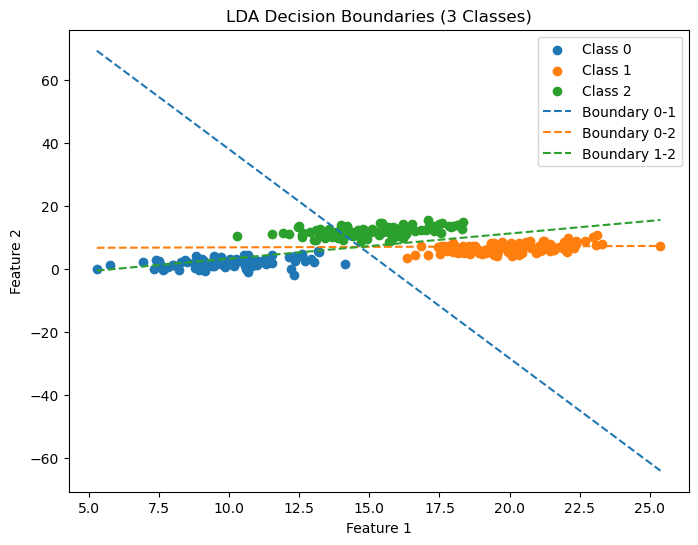

In [8]:
np.random.seed(2202)

X1 = np.random.multivariate_normal([10, 2], [[3, 1], [1, 2]], 100)
X2 = np.random.multivariate_normal([20, 7], [[3, 1], [1, 2]], 100)
X3 = np.random.multivariate_normal([15, 12], [[3, 1], [1, 2]], 100)

X = np.vstack([X1, X2, X3])
y = np.array([0]*100 + [1]*100 + [2]*100)

model = lda_fit(X, y)

preds = lda_predict(model, X)
print("Accuracy:", np.mean(preds == y))
print(model)

plt.figure(figsize=(8,6))

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], label="Class 2")

classes = model["classes"]

for i in range(len(classes)-1):
    for j in range(i+1, len(classes)):
        k1 = classes[i]
        k2 = classes[j]

        # Compute boundary parameters
        w_diff = model["w"][k2] - model["w"][k1]
        b_diff = model["w0"][k2] - model["w0"][k1]

        # Line: w_diff[0]*x1 + w_diff[1]*x2 + b_diff = 0
        x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
        y_vals = -(b_diff + w_diff[0] * x_vals) / w_diff[1]

        plt.plot(x_vals, y_vals, linestyle="--", label=f"Boundary {k1}-{k2}")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("LDA Decision Boundaries (3 Classes)")
plt.show()

In [9]:
# Generate 3D toy data 
np.random.seed(1918)

mean1 = [10, 2, 5]
mean2 = [20, 7, 15]

cov = [[3, 1, 0.5],
       [1, 2, 0.3],
       [0.5, 0.3, 2]]

X1 = np.random.multivariate_normal(mean1, cov, 100)
X2 = np.random.multivariate_normal(mean2, cov, 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

# Train LDA 
model = lda_fit(X, y)

# Extract decision boundary parameters 
w = model["w"][1] - model["w"][0]
b = model["w0"][1] - model["w0"][0]

print("w:", w)
print("b:", b)

# Create grid for decision plane 
x_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)
y_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)

xx, yy = np.meshgrid(x_range, y_range)

# Plane equation: x3 = -(b + w1*x1 + w2*x2) / w3
zz = -(b + w[0]*xx + w[1]*yy) / w[2]

# Plot using Plotly 
fig = go.Figure()

# Class 0
fig.add_trace(go.Scatter3d(
    x=X[y==0][:,0],
    y=X[y==0][:,1],
    z=X[y==0][:,2],
    mode='markers',
    name='Class 0'
))

# Class 1
fig.add_trace(go.Scatter3d(
    x=X[y==1][:,0],
    y=X[y==1][:,1],
    z=X[y==1][:,2],
    mode='markers',
    name='Class 1'
))

# Decision boundary plane
fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.5,
    showscale=False,
    name='Decision Boundary'
))

# Layout
fig.update_layout(
    title="3D LDA Decision Boundary",
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Feature 3'
    )
)

fig.show()

w: [2.2484434  0.93106251 4.65710058]
b: -83.60584050249112


<a class="anchor" id="library"></a>
# 9. LDA library

```python
# 1. Linear Discriminant Analysis (scikit-learn)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Basic model
model1 = LinearDiscriminantAnalysis(
    solver="svd", # solver: "svd", "lsqr", "eigen"
    shrinkage=None, # regularization (None, "auto", or float; only for "lsqr"/"eigen")
    priors=None, # class priors (default: inferred from data)
    n_components=None # number of components for dimensionality reduction
)

model1.fit(X, y)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy
model1.coef_ # linear coefficients (weights)
model1.intercept_ # bias term


# 2. LDA with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "solver": ["svd", "lsqr", "eigen"],
    "shrinkage": [None, "auto", 0.1, 0.5, 0.9]  # only valid for "lsqr" and "eigen"
}

model2 = GridSearchCV(
    estimator=LinearDiscriminantAnalysis(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_


# 3. LDA for Dimensionality Reduction
# (project data onto most discriminative directions)
model3 = LinearDiscriminantAnalysis(
    n_components=1 # must be <= number of classes - 1
)

X_reduced = model3.fit_transform(X, y)

X_reduced.shape # transformed feature space


# 4. LDA with automatic shrinkage (useful for high-dimensional data)
model4 = LinearDiscriminantAnalysis(
    solver="lsqr",
    shrinkage="auto" # Ledoit-Wolf shrinkage
)

model4.fit(X, y)

model4.score(X, y)
```

In [10]:
np.random.seed(1918)
X1 = np.random.multivariate_normal([10, 2], [[3, 1], [1, 2]], 100)
X2 = np.random.multivariate_normal([20, 7], [[3, 1], [1, 2]], 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

# Initialize model
model_lib = LinearDiscriminantAnalysis(
    solver="svd"  # default solver
)

# Train
model_lib.fit(X, y)

# Predict class labels
preds = model_lib.predict(X)
print("Predictions:", preds)

# Predict class probabilities
probs = model_lib.predict_proba(X)
print("Probabilities:\n", probs[:5])  # first 5 examples

# Accuracy
print("Accuracy:", model_lib.score(X, y))

# Model parameters
print("Coefficients (w):", model_lib.coef_)
print("Intercept (w0):", model_lib.intercept_)

# Compare Linear Discriminant parameters from library and self implementation
model = lda_fit(X, y)
coeffs_w=[model["w"][np.int64(1)][0]-model["w"][np.int64(0)][0],
          model["w"][np.int64(1)][1]-model["w"][np.int64(0)][1]]

interc_w0=model["w0"][np.int64(1)]-model["w0"][np.int64(0)]
print("Coefficients (w):",coeffs_w)
print("Intercept (w0):",interc_w0)

Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Probabilities:
 [[9.99999808e-01 1.91579037e-07]
 [9.99998418e-01 1.58238629e-06]
 [1.00000000e+00 1.96255368e-10]
 [9.99999999e-01 5.45729422e-10]
 [1.00000000e+00 3.37728221e-15]]
Accuracy: 1.0
Coefficients (w): [[3.10274158 1.60655251]]
Intercept (w0): [-53.78946209]
Coefficients (w): [np.float64(3.1027415789871564), np.float64(1.606552505131554)]
Intercept (w0): -53.789462091068174
